<a href="https://colab.research.google.com/github/Maryam-Skaik/parkinsons-disease-classification/blob/main/Parkinson%E2%80%99s_Disease_(PD)_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parkinson's Disease Classification

In this notebook, I will build a classification model to predict whether a person has Parkinson's Disease (PD) based on speech features. The dataset contains voice features extracted from Parkinson's Disease patients and healthy individuals. The goal is to predict whether a person is sick (class 1) or healthy (class 0) based on these features.

## Approach:
1. Load and preprocess the dataset.
2. Split the data into training and testing sets.
3. Train a logistic regression model.
4. Evaluate the model using various metrics.
5. Optimize the decision threshold to improve precision.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, \
ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

## Define Custom Functions


In [2]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay
def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)

  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)

  ## CONFUSION MATRICES SUBPLOT
  fig, axes = plt.subplots(ncols=2, figsize=figsize)

  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None, cmap='gist_gray',colorbar=colorbar, ax = axes[0],);
  axes[0].set_title("Raw Counts")

  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize, cmap=cmap,colorbar=colorbar, ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  fig.tight_layout()
  plt.show()
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test, figsize=(6,4), normalize='true', output_dict = False, cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, output_dict=True, figsize=figsize, colorbar=colorbar, cmap=cmap_train, label='Training Data')
  print()

  # Get predictions for test data
  y_test_pred = model.predict(X_test)

  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, output_dict=True,figsize=figsize, colorbar=colorbar, cmap=cmap_test, label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train, 'test': results_test}
    return results_dict

## Load dataset

In [16]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Week07/Data/pd_speech_features.csv'
df = pd.read_csv(fpath)

# Inspect data structure
df.info()
df.head()

# Target variable:
# class = 1 → Parkinson’s (sick)
# class = 0 → Healthy

# Observation:
# Dataset has very high dimensionality (~754 features) relative to number of samples (756)
# → This may lead to overfitting

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


### Step 1: Data Loading and Inspection

- We begin by importing the necessary libraries: `pandas` for data handling, `numpy` for numerical operations, and `matplotlib` for visualizations.
- The dataset is loaded from the provided file path into a DataFrame.
- The `df.info()` method provides an overview of the dataset, including the number of entries and the data types.
- The `df.head()` function is used to inspect the first few rows of the dataset to understand the structure and features available.

The dataset consists of 755 columns, including the target variable `class` (0 for healthy, 1 for sick). The features are numerical and correspond to various voice characteristics.

## Split the data to train and test

In [17]:
y = df['class']
X = df.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
y_train.value_counts(normalize=True)

,proportion
class,
1,0.751323
0,0.248677


### Step 2: Data Preprocessing

- The dataset contains a target variable `class` which indicates whether a person is healthy (0) or sick (1).
- We split the data into `X` (features) and `y` (target variable).
- The data is then split into training and testing sets using `train_test_split()`. The `stratify=y` ensures that the distribution of the target variable is preserved in both training and test sets.

### Note:
The dataset is **imbalanced** (more sick patients than healthy), so stratifying ensures that the train and test sets have a similar class distribution.

In [5]:
num_cols = X_train.select_dtypes('number').columns
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
num_pipe = make_pipeline(imputer, scaler)
num_tuple = ('num', num_pipe, num_cols)

In [6]:
preprocessor = ColumnTransformer([num_tuple])

### Step 3: Preprocessing Pipeline

- We handle missing values using `SimpleImputer(strategy='median')`, which replaces missing values with the median of each column.
- We then apply feature scaling using `StandardScaler()` to standardize the features.
- The `make_pipeline()` function combines the imputer and scaler into a single processing step.
- The `make_column_transformer()` allows us to apply the transformations to all numeric columns.

This pipeline ensures that the preprocessing steps are applied consistently across both training and test data.

## Fit a classification model

In [7]:
# Make an instance of the model
logreg = LogisticRegression(C = 1)

In [8]:
logreg_pipe = make_pipeline(preprocessor, logreg)

In [9]:
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses',
       'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter',
       ...
       'tqwt_kurtosisValue_dec_27', 'tqwt_kurtosisValue_dec_28',
       'tqwt_kurtosisValue_dec_29', 'tqwt_kurtosisValue_dec_30',
       'tqwt_kurtosisValue_dec_31', 'tqwt_kurtosisValue_dec_32',
       'tqwt_kurtosisValue_dec_33', 'tqwt_kurtosisValue_dec_34',
       'tqwt_kurtosisValue_dec_35', 'tqwt_kurtosisValue_dec_36'],
      dtype='object', length=754))])),
                ('logisticregression', LogisticRegression(C=1))])

### Step 4: Model Training

- We use **Logistic Regression** as the classification model for this task. Logistic regression is a simple yet effective model for binary classification problems.
- The hyperparameter `C` controls regularization. A smaller `C` means stronger regularization, helping to avoid overfitting.
- The model is trained using the preprocessed training data (`X_train`, `y_train`).

At this point, the model has been trained and is ready for evaluation.

## Evaluate the model quality on the train and test

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00       426

    accuracy                           1.00       567
   macro avg       1.00      1.00      1.00       567
weighted avg       1.00      1.00      1.00       567



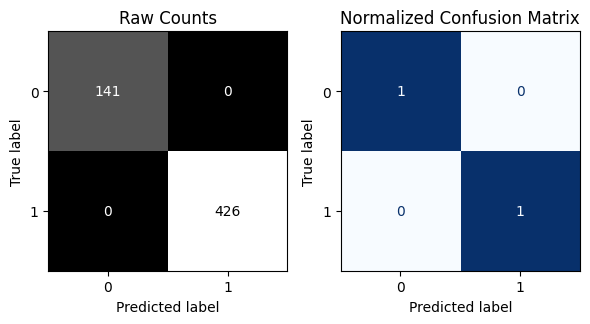


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.55      0.62        51
           1       0.85      0.92      0.88       138

    accuracy                           0.82       189
   macro avg       0.78      0.73      0.75       189
weighted avg       0.81      0.82      0.81       189



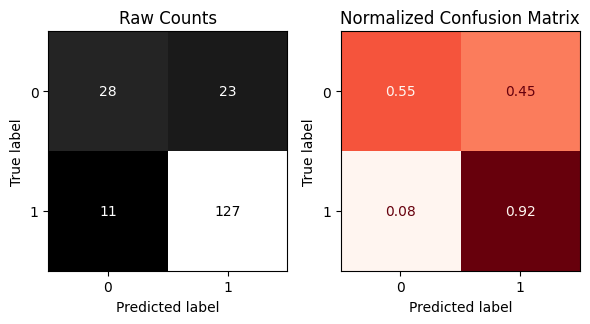

In [10]:
results = evaluate_classification(logreg_pipe, X_train, y_train, X_test, y_test)

### Step 5: Model Evaluation

- After training the model, we evaluate its performance on both the **training** and **test** sets.
- The `classification_report()` function provides precision, recall, and F1-score metrics for both classes (sick and healthy).
- We also plot the confusion matrix to visualize the true positives, false positives, true negatives, and false negatives.

The evaluation shows the model's ability to generalize, and we can observe if there's any overfitting based on the differences between training and test performance.

In [11]:
# Get the model probability predictions for the test set
test_probs = logreg_pipe.predict_proba(X_test)
test_probs[:5]

array([[9.49314824e-01, 5.06851760e-02],
       [9.21237171e-01, 7.87628292e-02],
       [1.28659869e-04, 9.99871340e-01],
       [9.99995935e-01, 4.06522659e-06],
       [3.68424035e-04, 9.99631576e-01]])

In [12]:
def convert_probs_to_preds(probabilities, threshold, pos_class=1):
  """Converts float value probabilities into int value predictions.
  If the probability of class 1 is greater than the threshold, the prediction is 1
  Otherwise the prediction is 0
  pos_class determines the index of the positive class in the array of probabilies"""
  predictions = [1 if prob[pos_class] > threshold else 0 for prob in probabilities]
  return predictions

In [13]:
# Create an array of float values between 0 and 1 with a step size of .05
thresholds = np.arange(start=0, stop=1.05, step=.05)
# Create empty recall and precision lists
recalls = []
precisions = []
accuracies = []
# Iterate over thresholds
for thresh in thresholds:
  # Convert probabilities to predictions according to each threshold
  preds = convert_probs_to_preds(test_probs, thresh)
  # Record the recall and precision for predictions at that threshold
  recalls.append(recall_score(y_test, preds))
  precisions.append(precision_score(y_test, preds))
  accuracies.append(accuracy_score(y_test, preds))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


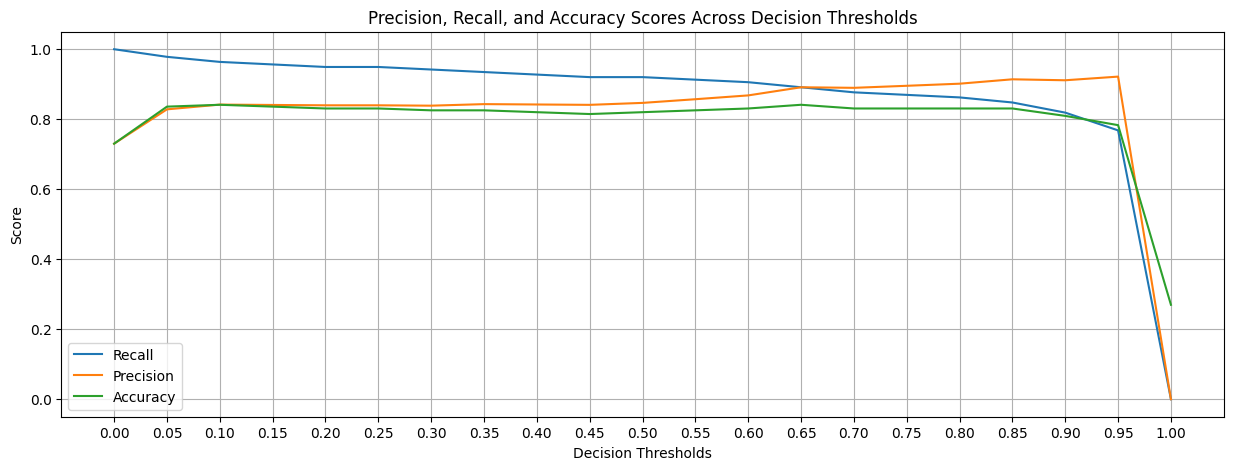

In [14]:
# Plot precisions and recalls for each probability
plt.figure(figsize=(15,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, accuracies, label='Accuracy')
plt.legend()
plt.title('Precision, Recall, and Accuracy Scores Across Decision Thresholds')
plt.xlabel('Decision Thresholds')
plt.ylabel('Score')
plt.grid()
plt.xticks(thresholds)
plt.show()

### Step 6: Threshold Adjustment

- We aim to adjust the **decision threshold** to improve precision, given that predicting a healthy person as sick can be harmful.
- The model's `predict_proba()` method returns the probability of the positive class (sick) for each sample.
- We test different thresholds (0.0 to 1.0) and observe how precision, recall, and accuracy change.
- The **precision** increases significantly at higher thresholds, as we require stronger evidence (higher probability) to predict a person as sick.

### Key Insight:
By increasing the threshold, we ensure that the model only classifies patients as sick when it is highly confident, minimizing the risk of incorrectly treating healthy individuals.

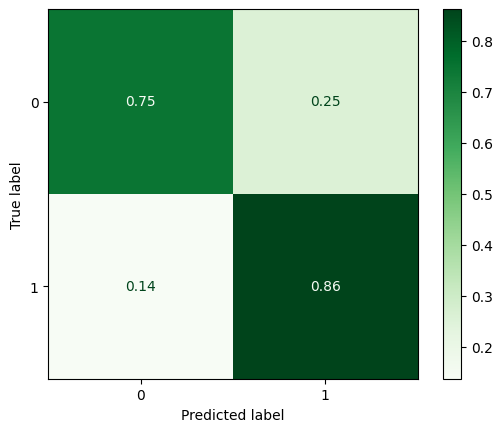

              precision    recall  f1-score   support

           0       0.67      0.75      0.70        51
           1       0.90      0.86      0.88       138

    accuracy                           0.83       189
   macro avg       0.78      0.80      0.79       189
weighted avg       0.84      0.83      0.83       189



In [15]:
# Convert probabilites to class labels with a decision threshold of 0.8
test_preds = convert_probs_to_preds(test_probs, .8)
# Display a confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, normalize='true',
                                        cmap='Greens')
plt.show()
# Print a classification report
print(classification_report(y_test, test_preds))

### Step 7: Final Evaluation

- After adjusting the threshold to 0.8, we evaluate the model on the test set again.
- The confusion matrix and classification report show the final results, including precision, recall, and F1-score.

### Conclusion:
- The precision improves significantly (90% for sick class), which reduces the risk of giving treatment to healthy individuals.
- The recall slightly decreases, which is acceptable as we are prioritizing precision to avoid false positives.

# Conclusion

In this notebook, we successfully built a classification model to predict whether a person has Parkinson’s Disease based on speech features. The following steps were completed:

1. **Data preprocessing**: Handling missing values and scaling features.
2. **Model training**: Using logistic regression to classify patients as healthy or sick.
3. **Model evaluation**: We evaluated the model using classification metrics like precision, recall, and F1-score.
4. **Threshold adjustment**: We increased the decision threshold to prioritize precision, minimizing the risk of false positives.

This model now has a good balance between precision and recall, making it suitable for medical decision-making. Future improvements could include feature selection or dimensionality reduction to reduce the risk of overfitting.